# ResNet-50 Evaluation and Visualization

In [1]:
import os
import sys

import pandas as pd
import tensorflow as tf

# Add the parent directory to the Python path to allow imports from sibling directories
sys.path.append(os.path.abspath(".."))

from data.dataset import prepare_cifar10_dataset, prepare_imagenette_dataset
from models.resnet50 import ResNet50
from utils.trainer import ResNetTrainer
from utils.visualize import plot_training_hist_df, plot_confusion_matrix, plot_sample_predictions

# Check TensorFlow version and available devices
print("TensorFlow Version:", tf.__version__)
print("Devices available:", tf.config.list_physical_devices())

c:\Users\87vla\anaconda3\envs\dl_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow Version: 2.21.0
Devices available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Evaluation on CIFAR-10 dataset

In [ ]:
DATASET_NAME = "cifar10"
BATCH_SIZE = 64

_, _, test_ds = prepare_cifar10_dataset(batch_size=BATCH_SIZE)
input_shape = (32, 32, 3)

print(f"\nSuccessfully loaded CIFAR-10 data pipelines.")

CIFAR-10 Shapes: (50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)

Successfully loaded CIFAR-10 data pipelines.


In [ ]:
# Paths for saved model and weights
BEST_MODEL_PATH_CIF = f"../saved_models/resnet50_{DATASET_NAME}_best_model.keras"

# Option A: Load full saved model (.keras)
if os.path.exists(BEST_MODEL_PATH_CIF):
    model = tf.keras.models.load_model(BEST_MODEL_PATH_CIF)
    print("Best model loaded successfully.")
else:
    raise FileNotFoundError("No saved model or weights found. Please train the model first.")

Best model loaded successfully.


In [ ]:
# Display network architecture summary
model.summary()

Training history loaded successfully.


,epoch,accuracy,loss,top_2_accuracy,val_accuracy,val_loss,val_top_2_accuracy
0,0,0.252022,3.312859,0.429533,0.3792,2.268433,0.5814
1,1,0.390733,1.762548,0.606133,0.4580,1.497358,0.6782
2,2,0.440311,1.553750,0.654822,0.4728,1.532007,0.6850
3,3,0.475822,1.457075,0.686111,0.5108,1.367579,0.7220
4,4,0.500578,1.383080,0.709733,0.5238,1.390632,0.7336


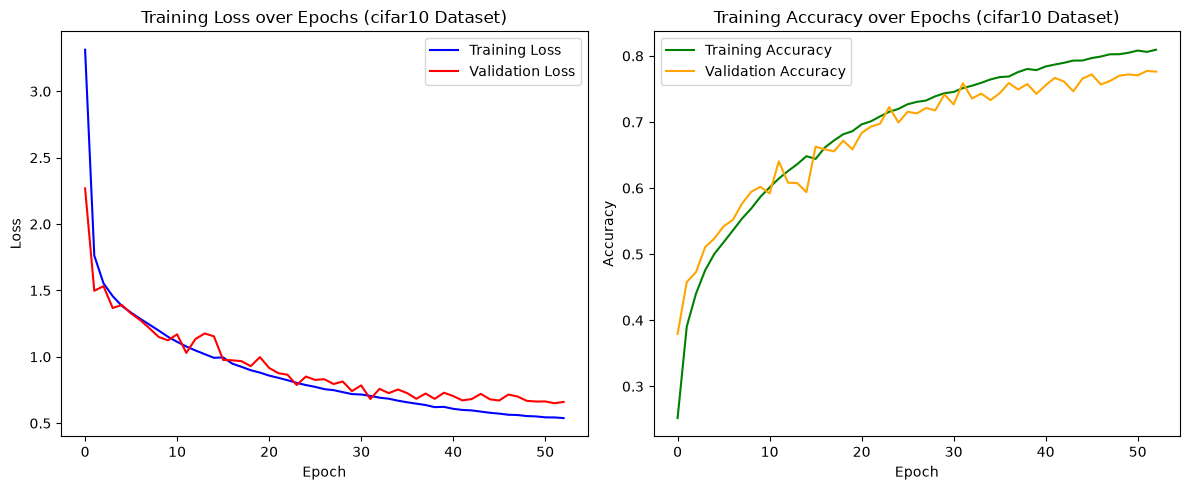

In [ ]:
HISTORY_PATH = f"../saved_models/resnet50_{DATASET_NAME}_history.csv"

if os.path.exists(HISTORY_PATH):
    # Load history from CSV file into a Pandas DataFrame
    history_df = pd.read_csv(HISTORY_PATH)
    print("Training history loaded successfully.")
    display(history_df.head())
else:
    raise FileNotFoundError(f"History file not found at: {HISTORY_PATH}")

# Plot training & validation loss and accuracy curves across epochs
plot_training_hist_df(history_df, dataset_name=DATASET_NAME)

In [ ]:
trainer = ResNetTrainer(model=model)

# Evaluate model performance on unseen test data
results = trainer.evaluate(test_ds, dataset_name=DATASET_NAME)

print(f"Test Accuracy ({DATASET_NAME.upper()}): {results['accuracy'] * 100:.2f}%")
print(f"Test Loss ({DATASET_NAME.upper()}): {results['loss']:.4f}")

--- Evaluating ResNet-5 on (cifar10) Test Data ---
157/157 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.7580 - loss: 0.7342 - top_2_accuracy: 0.8936
Test Accuracy (CIFAR10): 75.80%
Test Loss (CIFAR10): 0.7342


157/157 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step


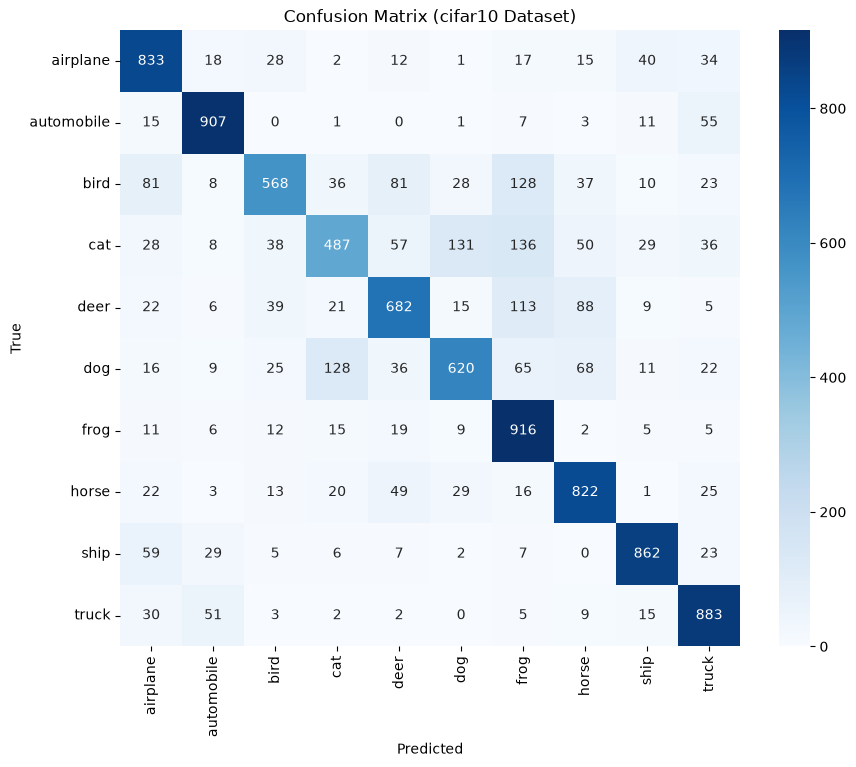

In [ ]:
# Generate and display normalized confusion matrix heatmap
plot_confusion_matrix(model=model, dataset=test_ds, dataset_name=DATASET_NAME)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


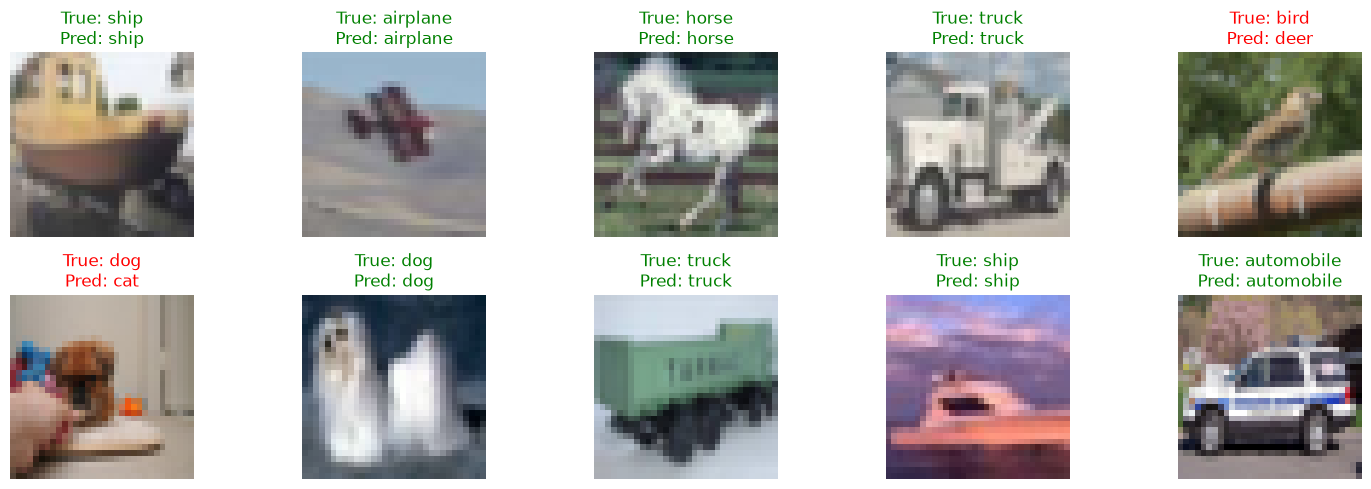

In [ ]:
# Visualize random test set samples with green/red prediction status labels
plot_sample_predictions(
    model=model,
    dataset=test_ds,
    dataset_name=DATASET_NAME,
    num_samples=10
)

## Evaluation on Imagenette dataset

In [ ]:
DATASET_NAME = "imagenette"
BATCH_SIZE = 64

_, _, test_ds = prepare_imagenette_dataset(batch_size=BATCH_SIZE)
input_shape = (32, 32, 3)

print(f"\nSuccessfully loaded CIFAR-10 data pipelines.")

Imagenette Processed Shapes: (8522, 160, 160, 3) (8522,) (3925, 160, 160, 3) (3925,)

Successfully loaded CIFAR-10 data pipelines.


In [3]:
# Paths for saved model and weights
BEST_MODEL_PATH_CIF = f"../saved_models/resnet50_{DATASET_NAME}_best_model.keras"

# Option A: Load full saved model (.keras)
if os.path.exists(BEST_MODEL_PATH_CIF):
    model = tf.keras.models.load_model(BEST_MODEL_PATH_CIF)
    print("Best model loaded successfully.")
else:
    raise FileNotFoundError("No saved model or weights found. Please train the model first.")

Best model loaded successfully.


In [ ]:
# Display network architecture summary
model.summary()

Training history loaded successfully.


,epoch,accuracy,loss,top_2_accuracy,val_accuracy,val_loss,val_top_2_accuracy
0,2,0.269655,2.167694,0.418798,0.307286,1.934310,0.488912
1,3,0.326567,1.947935,0.501877,0.370644,2.001259,0.536431
2,4,0.379723,1.839161,0.559141,0.380148,1.819096,0.565998
3,5,0.408238,1.766079,0.597043,0.372756,1.988251,0.557550
4,6,0.443558,1.657820,0.631425,0.438226,1.770691,0.624076


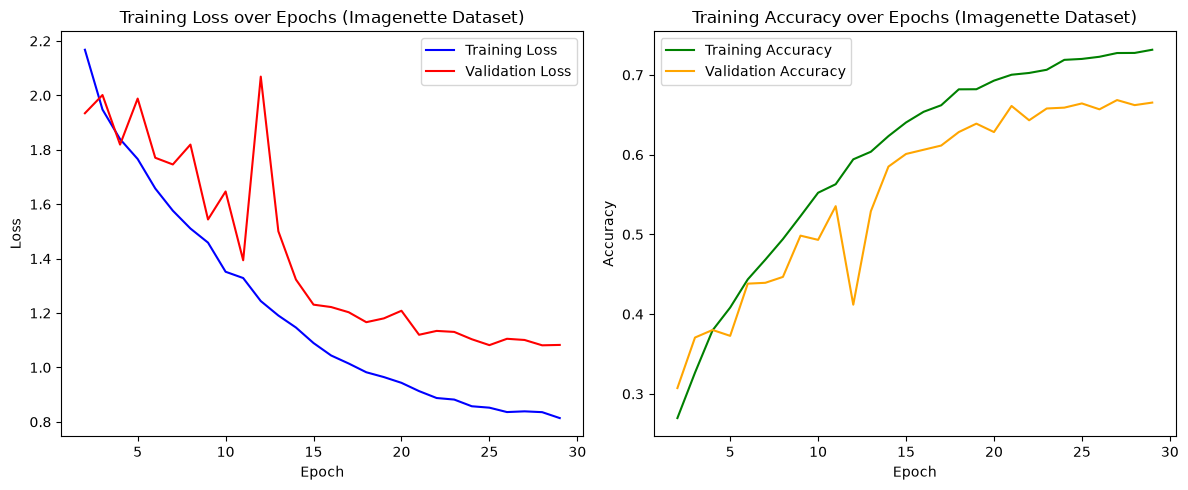

In [4]:
HISTORY_PATH = f"../saved_models/resnet50_{DATASET_NAME}_history.csv"

if os.path.exists(HISTORY_PATH):
    # Load history from CSV file into a Pandas DataFrame
    history_df = pd.read_csv(HISTORY_PATH)
    print("Training history loaded successfully.")
    display(history_df.head())
else:
    raise FileNotFoundError(f"History file not found at: {HISTORY_PATH}")

# Plot training & validation loss and accuracy curves across epochs
plot_training_hist_df(history_df, dataset_name=DATASET_NAME)

In [5]:
trainer = ResNetTrainer(model=model)

# Evaluate model performance on unseen test data
results = trainer.evaluate(test_ds, dataset_name=DATASET_NAME)

print(f"Test Accuracy ({DATASET_NAME.upper()}): {results['accuracy'] * 100:.2f}%")
print(f"Test Loss ({DATASET_NAME.upper()}): {results['loss']:.4f}")

--- Evaluating ResNet-50 on (Imagenette) Test Data ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.6540 - loss: 1.0777 - top_2_accuracy: 0.8028
Test Accuracy (IMAGENETTE): 65.40%
Test Loss (IMAGENETTE): 1.0777


62/62 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step


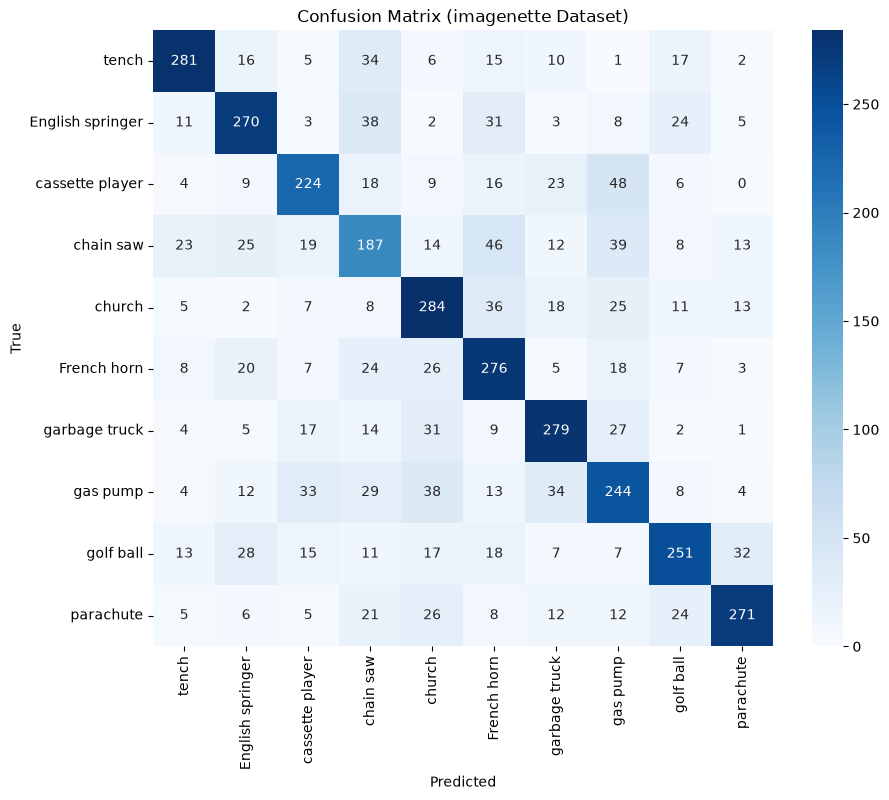

In [8]:
# Generate and display normalized confusion matrix heatmap
plot_confusion_matrix(model=model, dataset=test_ds, dataset_name=DATASET_NAME)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


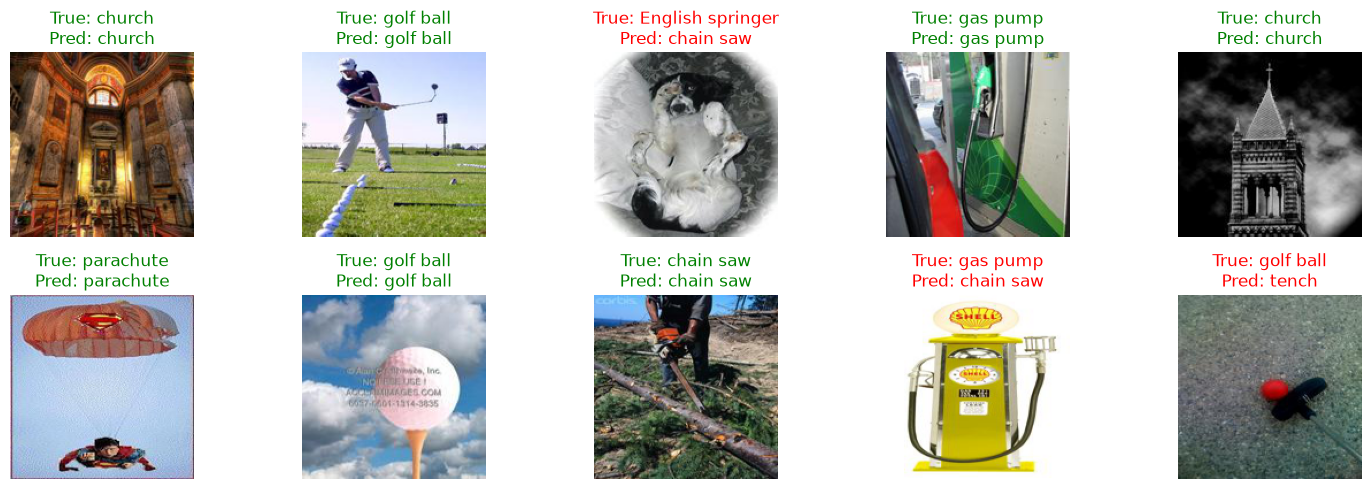

In [9]:
# Visualize random test set samples with green/red prediction status labels
plot_sample_predictions(
    model=model,
    dataset=test_ds,
    dataset_name=DATASET_NAME,
    num_samples=10
)